In [1]:
# AI-Powered Healthcare Disease Risk Prediction System

print("Healthcare Disease Risk Prediction Project")
print("Phase 1 - Setup Started")

Healthcare Disease Risk Prediction Project
Phase 1 - Setup Started


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("Dataset Information:")
print()

df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["Outcome"].value_counts())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunct

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
zero_counts = (df == 0).sum()

print("Zero values in each column:")
print(zero_counts)


Zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [7]:
import numpy as np

# Columns where zero represents a missing/invalid measurement
columns_with_zero_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace 0 with NaN
df[columns_with_zero_missing] = df[columns_with_zero_missing].replace(0, np.nan)

print("Zero values converted to missing values.")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Zero values converted to missing values.

Missing values after cleaning:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [8]:
# Fill missing values with the median of each column

for column in columns_with_zero_missing:
    df[column] = df[column].fillna(df[column].median())

print("Missing values filled successfully!")

print("\nMissing values after filling:")
print(df.isnull().sum())

Missing values filled successfully!

Missing values after filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


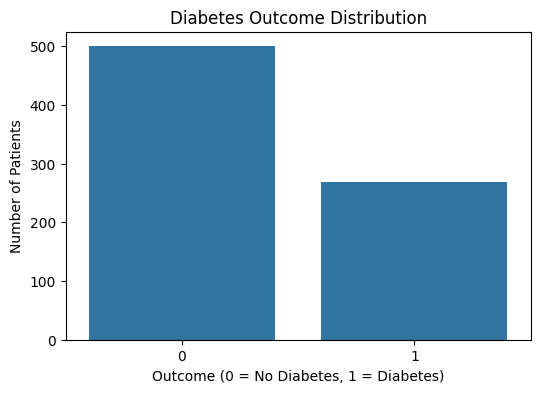

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

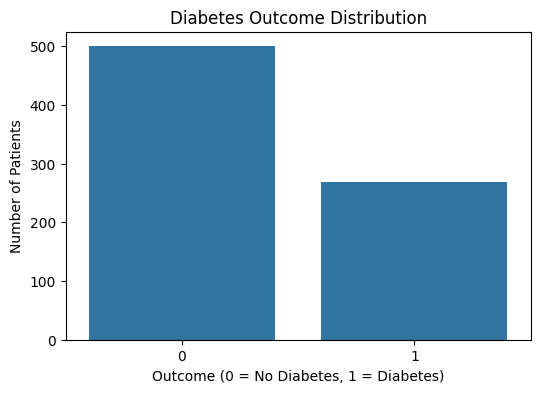

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

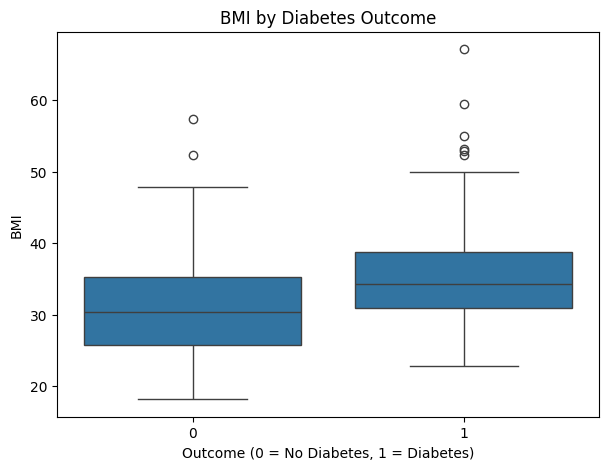

In [11]:
plt.figure(figsize=(7, 5))

sns.boxplot(x="Outcome", y="BMI", data=df)

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("BMI")

plt.show()

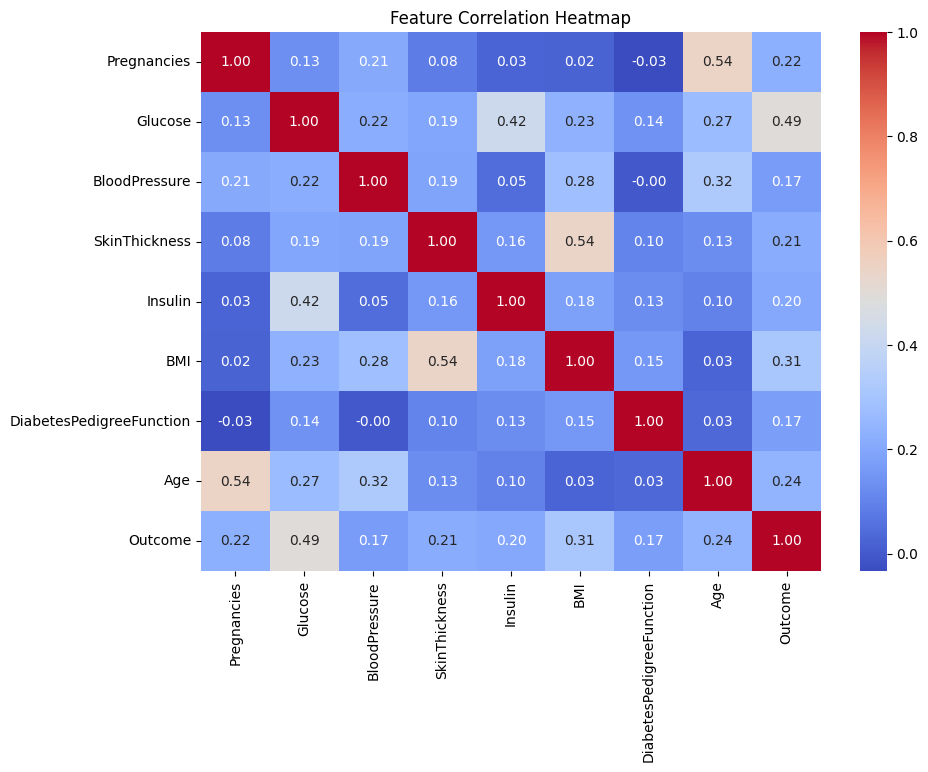

In [12]:
plt.figure(figsize=(10, 7))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
# Separate features and target

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (768, 8)
Target shape: (768,)

Feature columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)


Training data: (614, 8)
Testing data: (154, 8)

Training target: (614,)
Testing target: (154,)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

print("\nScaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed!

Scaled training data shape: (614, 8)
Scaled testing data shape: (154, 8)


In [16]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [17]:
# Make predictions on the test data

y_pred = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("\nFirst 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 predictions:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Probability predictions for ROC-AUC
y_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_probability)

print("Model Evaluation Results")
print("-------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Model Evaluation Results
-------------------------
Accuracy  : 0.7078
Precision : 0.6000
Recall    : 0.5000
F1 Score  : 0.5455
ROC-AUC   : 0.8130


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [20]:
# Make predictions using Random Forest

rf_pred = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("\nFirst 20 predictions:")
print(rf_pred[:20])

Random Forest predictions generated successfully!

First 20 predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]


In [21]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# Probability predictions for ROC-AUC
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print("Random Forest Evaluation Results")
print("---------------------------------")
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")

Random Forest Evaluation Results
---------------------------------
Accuracy  : 0.7403
Precision : 0.6522
Recall    : 0.5556
F1 Score  : 0.6000
ROC-AUC   : 0.8161


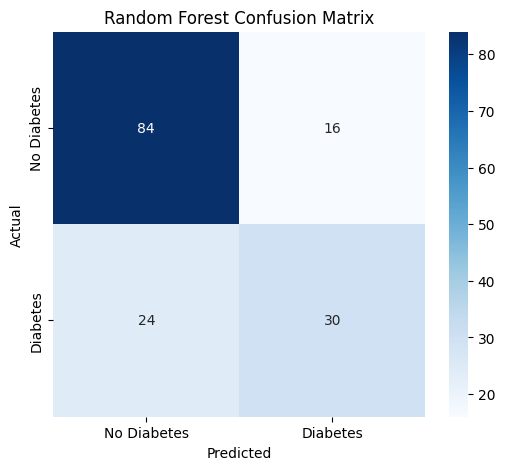

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
!pip install xgboost -q

In [24]:
from xgboost import XGBClassifier

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [25]:
# Make predictions using XGBoost

xgb_pred = xgb_model.predict(X_test)

print("XGBoost predictions generated successfully!")
print("\nFirst 20 predictions:")
print(xgb_pred[:20])

XGBoost predictions generated successfully!

First 20 predictions:
[1 0 0 1 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]


In [26]:
# Evaluate XGBoost

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

# Probability predictions for ROC-AUC
xgb_probability = xgb_model.predict_proba(X_test)[:, 1]
xgb_roc_auc = roc_auc_score(y_test, xgb_probability)

print("XGBoost Evaluation Results")
print("--------------------------")
print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}")

XGBoost Evaluation Results
--------------------------
Accuracy  : 0.7597
Precision : 0.6735
Recall    : 0.6111
F1 Score  : 0.6408
ROC-AUC   : 0.8270


In [27]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Random Forest,0.740260,0.652174,0.555556,0.600000,0.816111
2,XGBoost,0.759740,0.673469,0.611111,0.640777,0.827037


In [28]:
import shap

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")
print("SHAP values shape:", shap_values.shape)

SHAP values calculated successfully!
SHAP values shape: (154, 8)


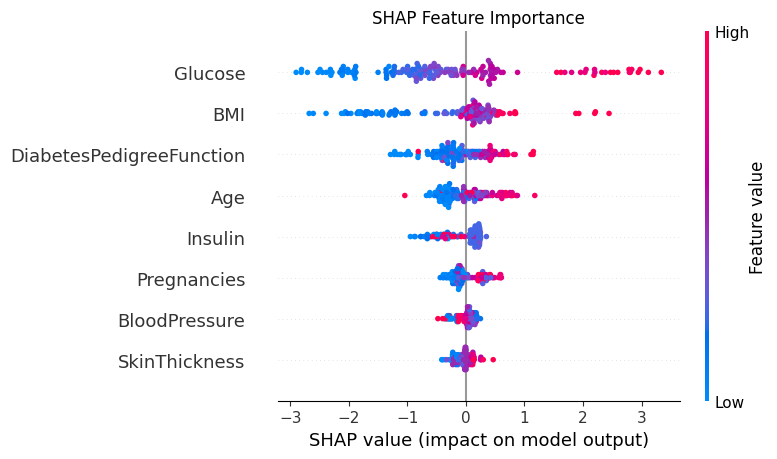

In [29]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [30]:
print("X_test shape:", X_test.shape)
print("SHAP values shape:", shap_values.shape)

X_test shape: (154, 8)
SHAP values shape: (154, 8)


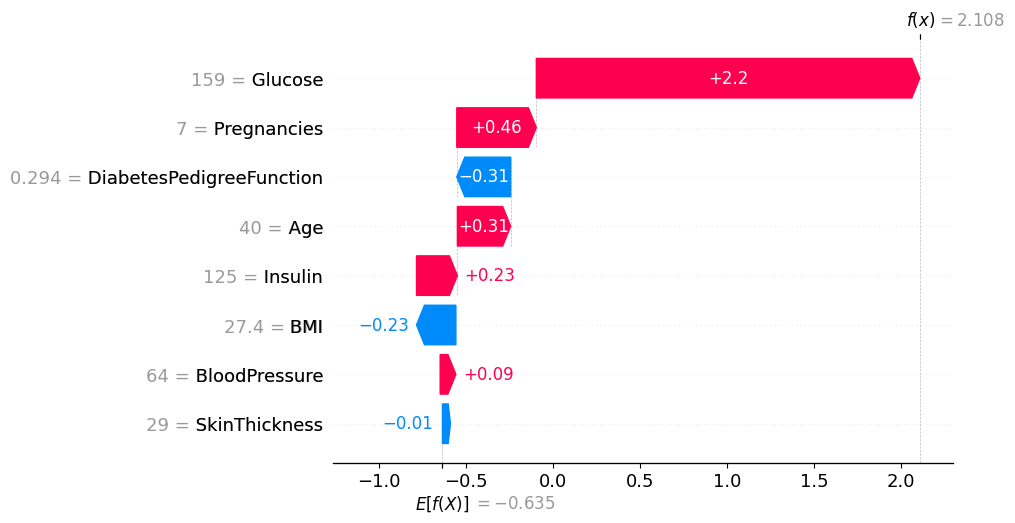

In [31]:
# Select one patient from the test dataset
patient_index = 0

patient_data = X_test.iloc[patient_index]

# Get SHAP values for this patient
patient_shap_values = shap_values[patient_index]

# Create SHAP explanation
patient_explanation = shap.Explanation(
    values=patient_shap_values,
    base_values=explainer.expected_value,
    data=patient_data.values,
    feature_names=X_test.columns
)

# Display the explanation
shap.plots.waterfall(patient_explanation, max_display=8)

In [32]:
# Get probability for the selected patient

patient_probability = xgb_model.predict_proba(
    X_test.iloc[[patient_index]]
)[0][1]

patient_prediction = xgb_model.predict(
    X_test.iloc[[patient_index]]
)[0]

print("Patient Prediction:", patient_prediction)
print(f"Risk Probability: {patient_probability * 100:.2f}%")

Patient Prediction: 1
Risk Probability: 89.17%


In [33]:
def get_risk_level(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"


risk_level = get_risk_level(patient_probability)

print(f"Risk Probability: {patient_probability * 100:.2f}%")
print(f"Risk Level: {risk_level}")

Risk Probability: 89.17%
Risk Level: High Risk


In [34]:
def predict_diabetes_risk(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    # Create input data
    input_data = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=X_train.columns)

    # Scale the input using the same scaler used during training
    input_scaled = scaler.transform(input_data)

    # Predict probability
    probability = xgb_model.predict_proba(input_scaled)[0][1]

    # Predict class
    prediction = xgb_model.predict(input_scaled)[0]

    # Determine risk level
    risk_level = get_risk_level(probability)

    return prediction, probability, risk_level

In [38]:
def predict_diabetes_risk(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    input_data = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=X_train.columns)

    prediction = xgb_model.predict(input_data)[0]
    probability = xgb_model.predict_proba(input_data)[0][1]

    risk_level = get_risk_level(probability)

    return prediction, probability, risk_level

In [39]:
prediction, probability, risk = predict_diabetes_risk(
    pregnancies=7,
    glucose=159,
    blood_pressure=64,
    skin_thickness=29,
    insulin=125,
    bmi=27.4,
    diabetes_pedigree=0.294,
    age=40
)

print("Prediction:", prediction)
print(f"Risk Probability: {probability * 100:.2f}%")
print("Risk Level:", risk)

Prediction: 1
Risk Probability: 89.17%
Risk Level: High Risk


In [37]:
# Direct prediction using the first test patient
direct_probability = xgb_model.predict_proba(
    X_test.iloc[[0]]
)[0][1]

direct_prediction = xgb_model.predict(
    X_test.iloc[[0]]
)[0]

print("Direct prediction:", direct_prediction)
print(f"Direct probability: {direct_probability * 100:.2f}%")

Direct prediction: 1
Direct probability: 89.17%


In [40]:
def explain_patient_risk(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    input_data = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=X_train.columns)

    # SHAP values for this patient
    patient_shap = explainer.shap_values(input_data)[0]

    # Create SHAP explanation
    explanation = shap.Explanation(
        values=patient_shap,
        base_values=explainer.expected_value,
        data=input_data.iloc[0].values,
        feature_names=input_data.columns
    )

    return explanation

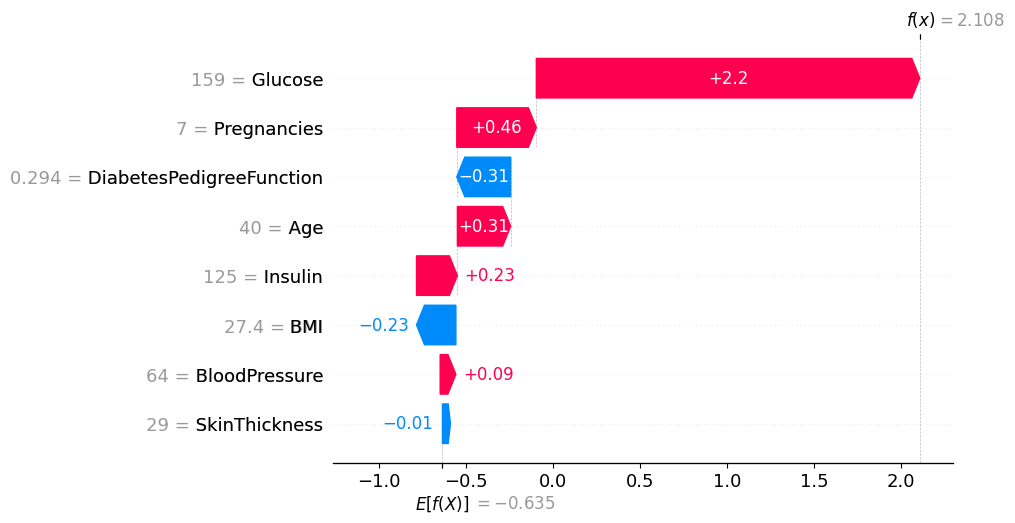

In [41]:
patient_explanation = explain_patient_risk(
    pregnancies=7,
    glucose=159,
    blood_pressure=64,
    skin_thickness=29,
    insulin=125,
    bmi=27.4,
    diabetes_pedigree=0.294,
    age=40
)

shap.plots.waterfall(patient_explanation, max_display=8)

In [42]:
def complete_diabetes_prediction(
    pregnancies,
    glucose,
    blood_pressure,
    skin_thickness,
    insulin,
    bmi,
    diabetes_pedigree,
    age
):
    # Create patient input
    input_data = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=X_train.columns)

    # Prediction
    prediction = xgb_model.predict(input_data)[0]

    # Probability
    probability = xgb_model.predict_proba(input_data)[0][1]

    # Risk level
    risk_level = get_risk_level(probability)

    # SHAP explanation
    patient_shap = explainer.shap_values(input_data)[0]

    explanation = shap.Explanation(
        values=patient_shap,
        base_values=explainer.expected_value,
        data=input_data.iloc[0].values,
        feature_names=input_data.columns
    )

    return prediction, probability, risk_level, explanation

In [43]:
prediction, probability, risk, explanation = complete_diabetes_prediction(
    pregnancies=7,
    glucose=159,
    blood_pressure=64,
    skin_thickness=29,
    insulin=125,
    bmi=27.4,
    diabetes_pedigree=0.294,
    age=40
)

print("========== DIABETES RISK RESULT ==========")
print("Prediction:", prediction)
print(f"Risk Probability: {probability * 100:.2f}%")
print("Risk Level:", risk)

========== DIABETES RISK RESULT ==========
Prediction: 1
Risk Probability: 89.17%
Risk Level: High Risk


In [44]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 51.3 MB/s eta 0:00:00


In [45]:
# Save trained XGBoost model
xgb_model.save_model("/content/diabetes_xgboost_model.json")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [46]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt


# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="AI Diabetes Risk Prediction",
    page_icon="🩺",
    layout="wide"
)


# --------------------------------------------------
# Load Model
# --------------------------------------------------

model = xgb.XGBClassifier()
model.load_model("/content/diabetes_xgboost_model.json")


# --------------------------------------------------
# Title
# --------------------------------------------------

st.title("🩺 AI-Based Diabetes Risk Prediction")
st.write(
    "Enter patient information to estimate diabetes risk "
    "using an XGBoost machine learning model."
)

st.warning(
    "This application provides risk estimation for educational "
    "and research purposes only. It is not a medical diagnosis."
)


# --------------------------------------------------
# Patient Input
# --------------------------------------------------

st.subheader("Patient Information")

col1, col2 = st.columns(2)

with col1:

    pregnancies = st.number_input(
        "Pregnancies",
        min_value=0,
        max_value=20,
        value=1
    )

    glucose = st.number_input(
        "Glucose",
        min_value=0.0,
        max_value=300.0,
        value=120.0
    )

    blood_pressure = st.number_input(
        "Blood Pressure",
        min_value=0.0,
        max_value=200.0,
        value=70.0
    )

    skin_thickness = st.number_input(
        "Skin Thickness",
        min_value=0.0,
        max_value=100.0,
        value=20.0
    )


with col2:

    insulin = st.number_input(
        "Insulin",
        min_value=0.0,
        max_value=1000.0,
        value=80.0
    )

    bmi = st.number_input(
        "BMI",
        min_value=0.0,
        max_value=80.0,
        value=30.0
    )

    diabetes_pedigree = st.number_input(
        "Diabetes Pedigree Function",
        min_value=0.0,
        max_value=3.0,
        value=0.5
    )

    age = st.number_input(
        "Age",
        min_value=1,
        max_value=120,
        value=30
    )


# --------------------------------------------------
# Prediction
# --------------------------------------------------

if st.button("🔍 Predict Diabetes Risk", use_container_width=True):

    input_data = pd.DataFrame([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age
    ]], columns=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ])


    # Prediction
    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0][1]


    # Risk level
    if probability < 0.30:
        risk_level = "Low Risk"
    elif probability < 0.70:
        risk_level = "Medium Risk"
    else:
        risk_level = "High Risk"


    # --------------------------------------------------
    # Display Result
    # --------------------------------------------------

    st.subheader("Prediction Result")

    result_col1, result_col2 = st.columns(2)

    with result_col1:
        st.metric(
            "Risk Probability",
            f"{probability * 100:.2f}%"
        )

    with result_col2:
        st.metric(
            "Risk Level",
            risk_level
        )


    if risk_level == "High Risk":
        st.error("⚠️ High predicted risk")

    elif risk_level == "Medium Risk":
        st.warning("⚠️ Medium predicted risk")

    else:
        st.success("✅ Low predicted risk")


    # --------------------------------------------------
    # SHAP Explanation
    # --------------------------------------------------

    st.subheader("🤖 Why did the AI make this prediction?")

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(input_data)

    patient_shap = shap_values[0]

    explanation = shap.Explanation(
        values=patient_shap,
        base_values=explainer.expected_value,
        data=input_data.iloc[0].values,
        feature_names=input_data.columns
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    shap.plots.waterfall(
        explanation,
        max_display=8,
        show=False
    )

    st.pyplot(fig)

    st.info(
        "SHAP explains how each patient feature contributed "
        "to the model's prediction."
    )

Writing /content/app.py


In [47]:
!streamlit run /content/app.py &>/content/streamlit.log &

print("Streamlit application started!")

Streamlit application started!


In [48]:
!pip install pyngrok -q

In [50]:
from pyngrok import ngrok

ngrok.set_auth_token("3JmYQl74RLkmi2WwnirHbzwToe6_72ze7bgrggTMVJLd7vJ7N")

print("ngrok authentication configured successfully!")

ngrok authentication configured successfully!


In [51]:
from pyngrok import ngrok

# Create public URL for Streamlit
public_url = ngrok.connect(8501)

print("====================================")
print("LIVE APPLICATION LINK:")
print(public_url)
print("====================================")

LIVE APPLICATION LINK:
NgrokTunnel: "https://spherical-dedicator-hunger.ngrok-free.dev" -> "http://localhost:8501"


In [52]:
import os

print("Current files:")
print(os.listdir())

Current files:
['.config', 'app.py', 'streamlit.log', 'diabetes_xgboost_model.json', 'sample_data']


In [53]:
import os

project_folder = "/content/AI_Diabetes_Risk_Prediction"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created successfully!")

Project folder created successfully!


In [54]:
import shutil
import os

project_folder = "/content/AI_Diabetes_Risk_Prediction"

shutil.copy("/content/app.py", project_folder)
shutil.copy("/content/diabetes_xgboost_model.json", project_folder)

print("Project files copied successfully!")
print(os.listdir(project_folder))

Project files copied successfully!
['app.py', 'diabetes_xgboost_model.json']


In [55]:
requirements = """streamlit
pandas
numpy
xgboost
shap
matplotlib
scikit-learn
"""

with open("/content/AI_Diabetes_Risk_Prediction/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [56]:
readme = """
# AI-Based Diabetes Risk Prediction

## Project Overview

This project uses Machine Learning and Explainable AI (XAI) to predict the risk of diabetes based on patient health-related features.

## Objective

The main objective is to build an AI-based system that predicts diabetes risk and explains the factors influencing the prediction.

## Dataset

The project uses a diabetes dataset containing 768 patient records and 8 input features.

### Features

- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

### Target

- Outcome

## Machine Learning Models

The following models were evaluated:

1. Logistic Regression
2. Random Forest
3. XGBoost

### Best Model

XGBoost achieved the best overall performance among the evaluated models.

- Accuracy: 75.97%
- Precision: 67.35%
- Recall: 61.11%
- F1 Score: 64.08%
- ROC-AUC: 82.70%

## Explainable AI

SHAP (SHapley Additive exPlanations) is used to explain individual predictions and identify which patient features contributed to the model's prediction.

## Application

A Streamlit web application was developed where users can enter patient information and receive:

- Diabetes risk prediction
- Risk probability
- Risk level
- SHAP-based explanation

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- XGBoost
- SHAP
- Matplotlib
- Streamlit

## Disclaimer

This application is intended for educational and research purposes only. It is not a medical diagnostic tool.
"""

with open(
    "/content/AI_Diabetes_Risk_Prediction/README.md",
    "w"
) as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [57]:
import os

project_folder = "/content/AI_Diabetes_Risk_Prediction"

print("Project Files:")
for file in os.listdir(project_folder):
    print("✓", file)

Project Files:
✓ app.py
✓ diabetes_xgboost_model.json
✓ requirements.txt
✓ README.md


In [58]:
import shutil

project_folder = "/content/AI_Diabetes_Risk_Prediction"

zip_path = shutil.make_archive(
    "/content/AI_Diabetes_Risk_Prediction",
    "zip",
    project_folder
)

print("ZIP created successfully!")
print(zip_path)

ZIP created successfully!
/content/AI_Diabetes_Risk_Prediction.zip


In [59]:
from google.colab import files

files.download("/content/AI_Diabetes_Risk_Prediction.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>